In [14]:
from dotenv import load_dotenv     # load HF token
load_dotenv()
import torch
from PIL import Image
from sam3.model.sam3_image_processor import Sam3Processor
print(torch.__version__)           # PyTorch Version: 2.10.0+cu128

if torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
print(DEVICE)

2.10.0+cu128
cuda


## Image example
### Compute the masks

In [6]:
from sam3.model_builder import build_sam3_image_model

# Load the model
model = build_sam3_image_model()
processor = Sam3Processor(model)

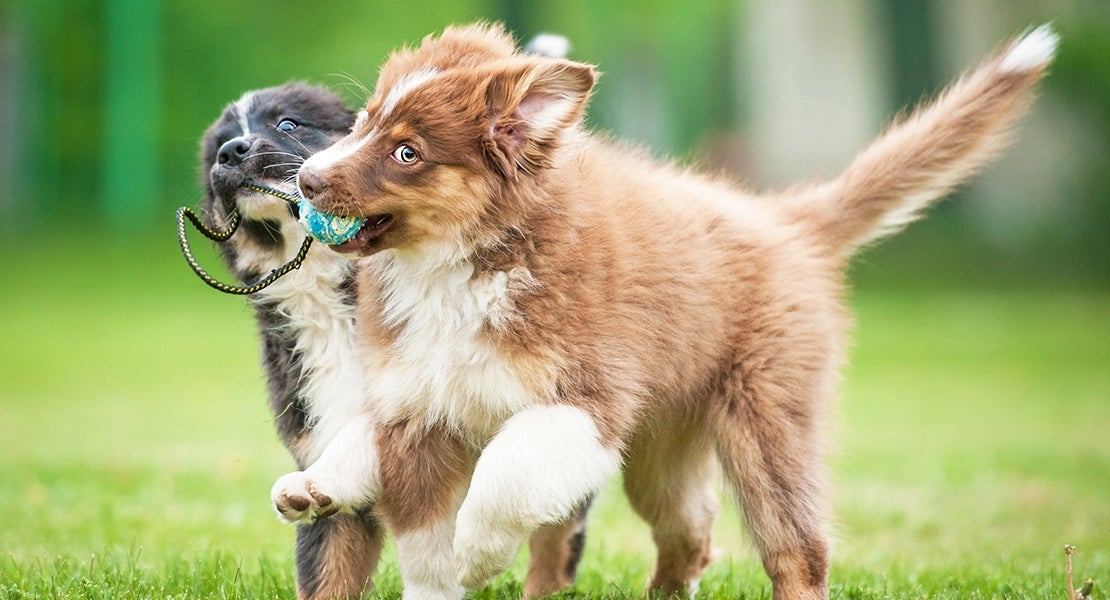

In [19]:
# Load an image
image_path = "test_media/dogs.jpg"
image = Image.open(image_path)
image

In [15]:
# inference + text prompt
IMAGE_TEXT_PROMPT = "dogs"

with torch.autocast(DEVICE, dtype=torch.bfloat16):
    inference_state = processor.set_image(image)
    output = processor.set_text_prompt(state=inference_state,
                                       prompt=IMAGE_TEXT_PROMPT)

In [16]:
# Get the masks, bounding boxes, and scores
masks, boxes, scores = output["masks"], output["boxes"], output["scores"]

### Visualization

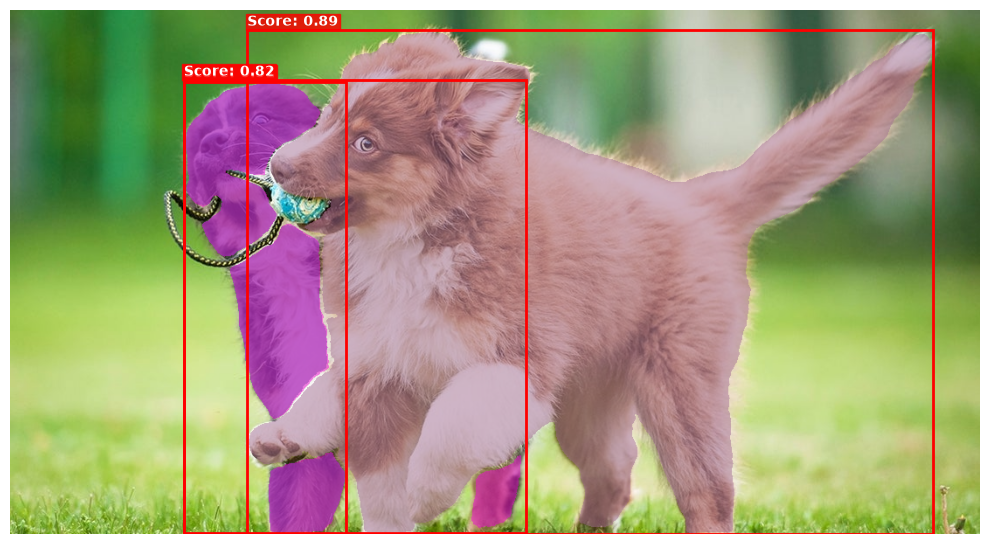

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

masks_np = masks.cpu().float().numpy()
boxes_np = boxes.cpu().float().numpy()
scores_np = scores.cpu().float().numpy()

plt.figure(figsize=(10, 10))
plt.imshow(image)
ax = plt.gca()

for i in range(len(masks_np)):
    # mask
    mask = masks_np[i]
    if len(mask.shape) == 3: 
        mask = mask[0] # Flatten from (1, H, W) to (H, W) if needed
        
    # random color + transparency
    color = np.concatenate([np.random.random(3), np.array([0.5])], axis=0)
    h, w = mask.shape
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)
    
    # box
    box = boxes_np[i]
    x_min, y_min, x_max, y_max = box
    rect = patches.Rectangle(
        (x_min, y_min), 
        x_max - x_min, 
        y_max - y_min, 
        linewidth=2, 
        edgecolor='red', 
        facecolor='none'
    )
    ax.add_patch(rect)
    
    # score
    score = scores_np[i]
    ax.text(
        x_min, y_min - 5, 
        f"Score: {score:.2f}", 
        color='white', 
        fontsize=10, 
        weight='bold', 
        bbox=dict(facecolor='red', edgecolor='red', alpha=0.8, pad=1)
    )

plt.axis('off')
plt.tight_layout()
plt.show()

## Video example

In [20]:
from sam3.model_builder import build_sam3_video_predictor
video_predictor = build_sam3_video_predictor()

INFO 2026-08-23 18:43:44,293 15224 sam3_video_predictor.py: 120: using the following GPU IDs: [0]
INFO 2026-08-23 18:43:44,316 15224 sam3_video_predictor.py: 136: 


	*** START loading model on all ranks ***


INFO 2026-08-23 18:43:44,316 15224 sam3_video_predictor.py: 138: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-08-23 18:44:12,250 15224 sam3_video_base.py: 354: setting max_num_objects=10000 and num_obj_for_compile=16


KeyboardInterrupt: 

In [ ]:
video_path = "test_media/dogs_playing.mp4"

# Start a session
response = video_predictor.handle_request(
    request=dict(
        type="start_session",
        resource_path=video_path,
    )
)

VIDEO_TEXT_PROMPT = "dogs"

response = video_predictor.handle_request(
    request=dict(
        type="add_prompt",
        session_id=response["session_id"],
        frame_index=0, # Arbitrary frame index
        text=VIDEO_TEXT_PROMPT,
    )
)
output = response["outputs"]